In [10]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

train_data_dir = '/content/gdrive/MyDrive/news dataset/development.csv'
eval_data_dir = '/content/gdrive/MyDrive/news dataset/evaluation.csv'

In [12]:
train_data = pd.read_csv(train_data_dir, delimiter=',',na_values=-1)
eval_data = pd.read_csv(eval_data_dir, delimiter=',',na_values=-1)
train_data = train_data.fillna(-1)
eval_data = eval_data.fillna(-1)

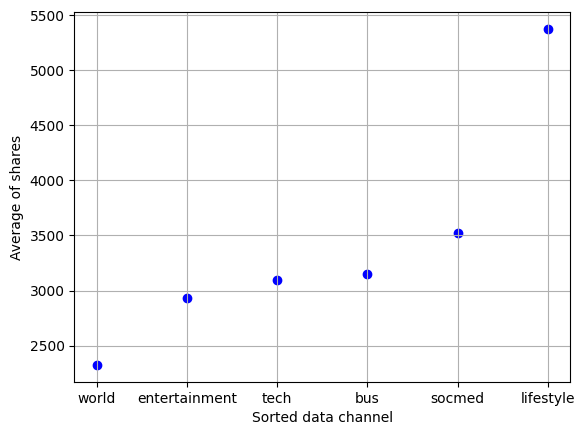

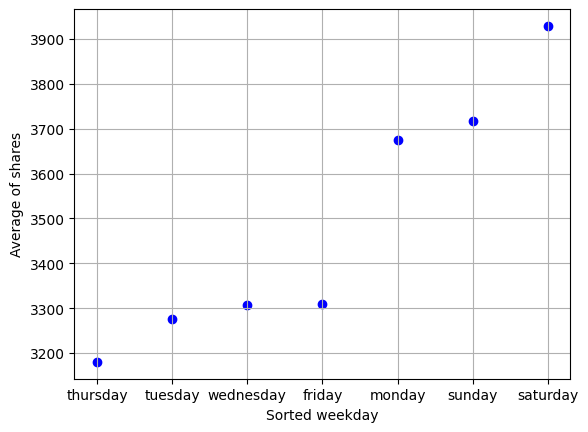

In [13]:
data_channel = np.unique(train_data['data_channel'].values)
mean_shares = np.zeros(data_channel.shape)
mean_shares[0] = np.mean(train_data['shares'][train_data['data_channel']==data_channel[0]])
mean_shares[1] = np.mean(train_data['shares'][train_data['data_channel']==data_channel[1]])
mean_shares[2] = np.mean(train_data['shares'][train_data['data_channel']==data_channel[2]])
mean_shares[3] = np.mean(train_data['shares'][train_data['data_channel']==data_channel[3]])
mean_shares[4] = np.mean(train_data['shares'][train_data['data_channel']==data_channel[4]])
mean_shares[5] = np.mean(train_data['shares'][train_data['data_channel']==data_channel[5]])

arg_sort = np.argsort(mean_shares)
data_channel = data_channel[arg_sort]
mean_shares = mean_shares[arg_sort]

plt.figure(0)
plt.scatter(data_channel, mean_shares, marker='o', color='b')
plt.xlabel('Sorted data channel')
plt.ylabel('Average of shares')
plt.grid()
plt.show()


weekday = np.unique(train_data['weekday'].values)
mean_shares = np.zeros(weekday.shape)
mean_shares[0] = np.mean(train_data['shares'][train_data['weekday']==weekday[0]])
mean_shares[1] = np.mean(train_data['shares'][train_data['weekday']==weekday[1]])
mean_shares[2] = np.mean(train_data['shares'][train_data['weekday']==weekday[2]])
mean_shares[3] = np.mean(train_data['shares'][train_data['weekday']==weekday[3]])
mean_shares[4] = np.mean(train_data['shares'][train_data['weekday']==weekday[4]])
mean_shares[5] = np.mean(train_data['shares'][train_data['weekday']==weekday[5]])
mean_shares[6] = np.mean(train_data['shares'][train_data['weekday']==weekday[6]])

arg_sort = np.argsort(mean_shares)
weekday = weekday[arg_sort]
mean_shares = mean_shares[arg_sort]

print()

plt.figure(1)
plt.scatter(weekday, mean_shares, marker='o', color='b')
plt.xlabel('Sorted weekday')
plt.ylabel('Average of shares')
plt.grid()
plt.show()

In [14]:
train_data['weekday'][train_data['weekday']==weekday[0]] = 0
train_data['weekday'][train_data['weekday']==weekday[1]] = 1
train_data['weekday'][train_data['weekday']==weekday[2]] = 2
train_data['weekday'][train_data['weekday']==weekday[3]] = 3
train_data['weekday'][train_data['weekday']==weekday[4]] = 4
train_data['weekday'][train_data['weekday']==weekday[5]] = 5
train_data['weekday'][train_data['weekday']==weekday[6]] = 6

eval_data['weekday'][eval_data['weekday']==weekday[0]] = 0
eval_data['weekday'][eval_data['weekday']==weekday[1]] = 1
eval_data['weekday'][eval_data['weekday']==weekday[2]] = 2
eval_data['weekday'][eval_data['weekday']==weekday[3]] = 3
eval_data['weekday'][eval_data['weekday']==weekday[4]] = 4
eval_data['weekday'][eval_data['weekday']==weekday[5]] = 5
eval_data['weekday'][eval_data['weekday']==weekday[6]] = 6


train_data['data_channel'][train_data['data_channel']==data_channel[0]] = 0
train_data['data_channel'][train_data['data_channel']==data_channel[1]] = 1
train_data['data_channel'][train_data['data_channel']==data_channel[2]] = 2
train_data['data_channel'][train_data['data_channel']==data_channel[3]] = 3
train_data['data_channel'][train_data['data_channel']==data_channel[4]] = 4
train_data['data_channel'][train_data['data_channel']==data_channel[5]] = 5

eval_data['data_channel'][eval_data['data_channel']==data_channel[0]] = 0
eval_data['data_channel'][eval_data['data_channel']==data_channel[1]] = 1
eval_data['data_channel'][eval_data['data_channel']==data_channel[2]] = 2
eval_data['data_channel'][eval_data['data_channel']==data_channel[3]] = 3
eval_data['data_channel'][eval_data['data_channel']==data_channel[4]] = 4
eval_data['data_channel'][eval_data['data_channel']==data_channel[5]] = 5

<ipython-input-14-0e385131f4f7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['weekday'][train_data['weekday']==weekday[0]] = 0
<ipython-input-14-0e385131f4f7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['weekday'][train_data['weekday']==weekday[1]] = 1
<ipython-input-14-0e385131f4f7>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['weekday'][train_data['weekday']==weekday[2]] = 2
<ipython-inpu

In [15]:
print('train data shape = ' + str(train_data.shape))
print('evaluation data shape = ' + str(eval_data.shape))

train data shape = (31715, 50)
evaluation data shape = (7917, 49)


In [16]:
np.histogram(train_data['shares'].values)
# For declaring the distribution

(array([31651,    46,     9,     4,     0,     1,     0,     2,     1,
            1]),
 array([4.000000e+00, 8.433360e+04, 1.686632e+05, 2.529928e+05,
        3.373224e+05, 4.216520e+05, 5.059816e+05, 5.903112e+05,
        6.746408e+05, 7.589704e+05, 8.433000e+05]))

0.51% of data have shares value more than 50000

Train size = (31554, 48)


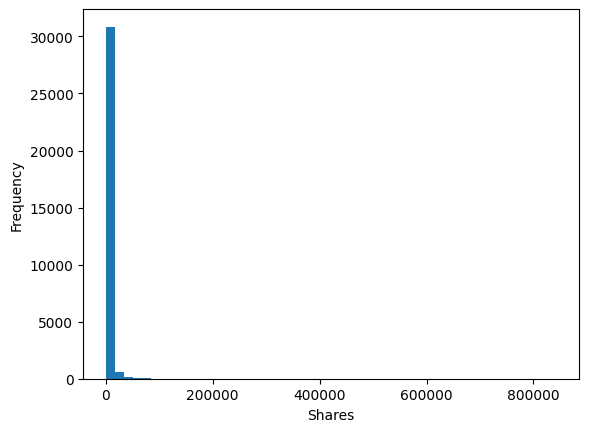

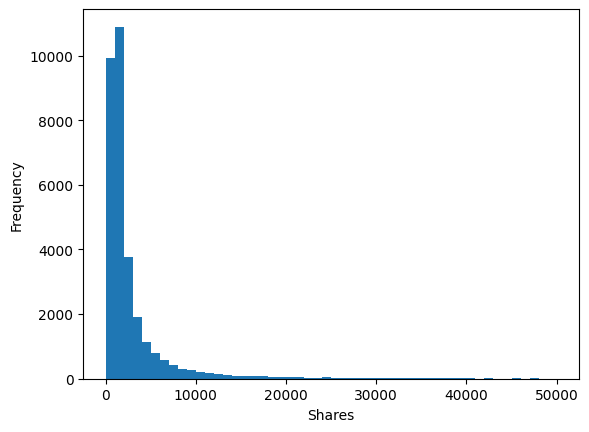

In [17]:
data_ndarray = np.array(train_data.values)
th = 50000

x_train_0_th = np.delete(data_ndarray, [1,-3], axis=1).astype(float)
y_train_0_th = data_ndarray[:,-3].astype(float)
print(str(np.round(np.sum(y_train_0_th>th)/y_train_0_th.shape[0]*100,2))+'% of data have shares value more than 50000')

plt.figure(0)
plt.hist(y_train_0_th,50)
plt.xlabel('Shares')
plt.ylabel('Frequency')
print()
x_train_0_th = np.delete(x_train_0_th, y_train_0_th>th, axis=0)
y_train_0_th = np.delete(y_train_0_th, y_train_0_th>th, axis=0)

plt.figure(1)
plt.hist(y_train_0_th,50)
plt.xlabel('Shares')
plt.ylabel('Frequency')


x_eval = np.delete(np.array(eval_data.values), [1], axis=1)


print('Train size = ' + str(x_train_0_th.shape))

In [18]:
# Split train and validation
valid_rate = 0.1
np.random.seed(seed=0)
valid_index = np.random.choice(x_train_0_th.shape[0], int(x_train_0_th.shape[0]*valid_rate), replace=False)

x_valid_0_th = x_train_0_th[valid_index, :]
y_valid_0_th = y_train_0_th[valid_index]

x_train_0_th = np.delete(x_train_0_th, valid_index, axis=0)
y_train_0_th = np.delete(y_train_0_th, valid_index, axis=0)

print('Train size = ' + str(x_train_0_th.shape))
print('Validation size = ' + str(x_valid_0_th.shape))



Train size = (28399, 48)
Validation size = (3155, 48)


In [19]:
# CNN model
input_layer = tf.keras.layers.Input(shape=[48,1])
l = tf.keras.layers.Conv1D(filters=64, kernel_size=2 , strides=1 , activation='linear', padding='valid',data_format='channels_last')(input_layer)
l = tf.keras.layers.PReLU()(l)
l = tf.keras.layers.Conv1D(filters=32, kernel_size=2 , strides=2 , activation='linear', padding='valid',data_format='channels_last')(l)
l = tf.keras.layers.PReLU()(l)
l = tf.keras.layers.Conv1D(filters=16, kernel_size=4 , strides=2 , activation='linear', padding='valid',data_format='channels_last')(l)
l = tf.keras.layers.PReLU()(l)
l = tf.keras.layers.Conv1D(filters=8, kernel_size=4 , strides=2 , activation='linear', padding='valid',data_format='channels_last')(l)
l = tf.keras.layers.PReLU()(l)
l = tf.keras.layers.Conv1D(filters=1, kernel_size=4 , strides=2 , activation='linear', padding='valid',data_format='channels_last')(l)
output_layer = tf.keras.layers.PReLU()(l)
CNN_model=tf.keras.Model(input_layer, output_layer)
CNN_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 1)]           0         
                                                                 
 conv1d (Conv1D)             (None, 47, 64)            192       
                                                                 
 p_re_lu (PReLU)             (None, 47, 64)            3008      
                                                                 
 conv1d_1 (Conv1D)           (None, 23, 32)            4128      
                                                                 
 p_re_lu_1 (PReLU)           (None, 23, 32)            736       
                                                                 
 conv1d_2 (Conv1D)           (None, 10, 16)            2064      
                                                                 
 p_re_lu_2 (PReLU)           (None, 10, 16)            160   

In [20]:
from keras.optimizers.schedules import learning_rate_schedule
from keras.callbacks import EarlyStopping

callback = EarlyStopping(monitor='rmse', patience=80, verbose=1, mode='min', baseline=None, restore_best_weights=True)


initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=200,
    decay_rate=0.99,
    staircase=True)

import keras.backend as K

def rmse (y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true), axis=-1))

print('Train CNN model')
CNN_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule), loss=tf.keras.losses.MSE,  metrics=rmse)
CNN_results=CNN_model.fit(x_train_0_th[:,:,np.newaxis], y_train_0_th[:,np.newaxis], validation_data=(x_valid_0_th[:,:,np.newaxis], y_valid_0_th[:,np.newaxis]), batch_size=32, epochs=100, shuffle=True, callbacks=[callback])


Train CNN model
Epoch 1/100
888/888 [==============================] - 11s 10ms/step - loss: 20834094.0000 - rmse: 2393.6338 - val_loss: 22062980.0000 - val_rmse: 2511.8972
Epoch 2/100
888/888 [==============================] - 6s 7ms/step - loss: 20191762.0000 - rmse: 2333.9956 - val_loss: 21435890.0000 - val_rmse: 2358.0186
Epoch 3/100
888/888 [==============================] - 8s 9ms/step - loss: 19640550.0000 - rmse: 2269.7866 - val_loss: 21190948.0000 - val_rmse: 2287.8828
Epoch 4/100
888/888 [==============================] - 6s 7ms/step - loss: 19432706.0000 - rmse: 2261.6106 - val_loss: 21005318.0000 - val_rmse: 2274.2974
Epoch 5/100
888/888 [==============================] - 8s 9ms/step - loss: 19386714.0000 - rmse: 2265.7280 - val_loss: 21189196.0000 - val_rmse: 2220.0156
Epoch 6/100
888/888 [==============================] - 6s 7ms/step - loss: 19280080.0000 - rmse: 2258.9265 - val_loss: 20810854.0000 - val_rmse: 2390.1736
Epoch 7/100
888/888 [==============================]

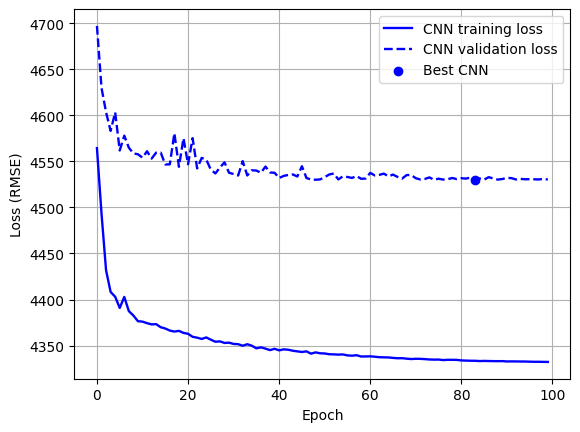

In [21]:
plt.figure(0)

plt.plot(CNN_results.epoch, np.sqrt(CNN_results.history['loss']), 'b', linewidth=1.7, label='CNN training loss')
plt.plot(CNN_results.epoch, np.sqrt(CNN_results.history['val_loss']), '--b', linewidth=1.7, label='CNN validation loss')
plt.scatter(CNN_results.epoch[np.argmin(CNN_results.history['val_loss'])], np.sqrt(np.min(CNN_results.history['val_loss'])), marker='o', color='b', label='Best CNN')

plt.xlabel('Epoch')
plt.ylabel('Loss (RMSE)')
plt.legend()
plt.grid()


In [22]:
y_pred_CNN = CNN_model.predict(x_eval.astype('float'))

248/248 [==============================] - 3s 8ms/step


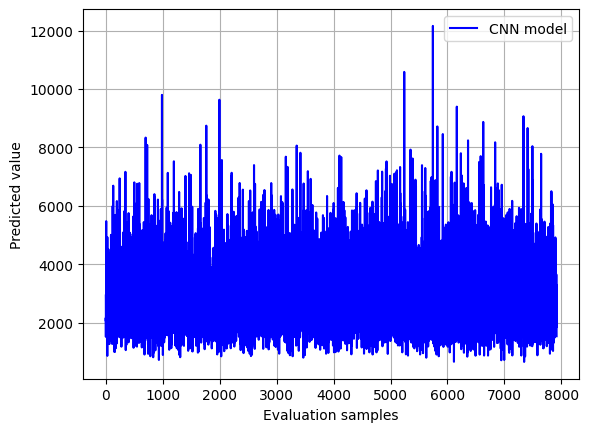

In [23]:

plt.figure(0)
plt.plot(y_pred_CNN[:,0], 'b', label='CNN model')
plt.xlabel('Evaluation samples')
plt.ylabel('Predicted value')
plt.legend()
plt.grid()

In [27]:
y_CNN = pd.DataFrame({'Id':(np.array(eval_data.values))[:,0], 'Predicted':y_pred_CNN[:,0,0]})

In [29]:
y_CNN.to_csv('/content/gdrive/MyDrive/111 sample_submission_CNN.csv', index=False)

In [ ]:
# save CNN model
model_json = CNN_model.to_json()
with open("/content/gdrive/MyDrive/CNN_model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
CNN_model.save_weights("/content/gdrive/MyDrive/CNN_model.h5")
print("Saved model to disk")


Saved model to disk


In [ ]:
# load CNN model
from tensorflow.keras.models import model_from_json
json_file = open('/content/gdrive/MyDrive/CNN_model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
CNN_model = model_from_json(loaded_model_json)
# load weights into new model
CNN_model.load_weights('/content/gdrive/MyDrive/CNN_model.h5')
print("Loaded model from disk")

Loaded model from disk


In [ ]:
y_pred_CNN = CNN_model.predict(x_eval.astype('float'))
y_CNN = pd.DataFrame({'Id':(np.array(eval_data.values))[:,0], 'Predicted':y_pred_CNN[:,0,0]})
y_CNN.to_csv('/content/gdrive/MyDrive/news dataset/sample_submission_CNN.csv', index=False)

248/248 [==============================] - 1s 3ms/step
